In [3]:
# ==============================================================
# MSBA – Optimization 2: Project 2
# Airline Ticket Pricing via Dynamic Programming
# ==============================================================
#
# OVERVIEW:
#   We model 365 days of ticket sales on a single flight.
#   The airline chooses a price each day for coach and for
#   first-class tickets. Demand is probabilistic — the higher
#   the price, the lower the chance someone buys that day.
#
#   Goal: find the pricing policy that maximizes the total
#   *expected discounted profit*, net of any overbooking costs
#   that arise if too many passengers show up on departure day.
#
# PART 1 — Solve the DP with a fixed overbooking allowance of 5.
# PART 2 — Sweep overbooking limits 5 through 20; find the best.

In [4]:
# --------------------------------------------------
# SECTION 1: Imports
# --------------------------------------------------

import numpy as np
from scipy.stats import binom
import matplotlib.pyplot as plt

In [5]:
# --------------------------------------------------
# SECTION 2: Global Parameters
# --------------------------------------------------
# All tunable numbers live here. Keeping them in one place
# makes the model easy to audit, adjust, and explain.

# --- Price options for each cabin (dollars per ticket) ---
COACH_PRICES = [300, 325, 350]
FIRST_PRICES = [425, 500]

# --- Base demand probabilities (chance of one sale per day) ---
# Lower price → higher probability. These are given by the problem.
COACH_DEMAND = {
    300: 0.65,
    325: 0.45,
    350: 0.30,
}

FIRST_DEMAND = {
    425: 0.08,
    500: 0.04,
}

# --- First-class spillover effect ---
# When first-class sells out, some would-be first-class buyers
# redirect their interest to coach. This adds a small boost
# to coach demand for the remainder of the selling period.
FIRST_SOLD_OUT_COACH_BOOST = 0.04

# --- Physical seating capacity ---
COACH_CAPACITY = 100    # seats on the plane for coach passengers
FIRST_CAPACITY = 20     # seats on the plane for first-class passengers

# --- Show-up rates (used at departure day) ---
# Not every ticket holder actually shows up. These no-show rates
# are what make overbooking a potentially profitable strategy.
COACH_SHOW_UP_PROB = 0.95
FIRST_SHOW_UP_PROB = 0.97

# --- Overbooking penalty costs ---
# When more coach passengers show up than there are seats:
#   Option A — bump them into first-class if a seat is open ($50)
#   Option B — deny boarding if first-class is also full ($425)
BUMP_TO_FIRST_COST   = 50
DENIED_BOARDING_COST = 425

# --- Daily discount factor ---
# A dollar of revenue collected today is worth slightly more than
# one collected tomorrow. We use a 17% annual rate, converted to
# a per-day multiplier via continuous-style daily compounding.
ANNUAL_DISCOUNT_RATE = 0.17
DAILY_DISCOUNT       = 1 / (1 + ANNUAL_DISCOUNT_RATE / 365)

# --- Selling horizon ---
SELLING_HORIZON = 365   # days before departure when ticket sales begin

In [6]:
# --------------------------------------------------
# SECTION 3: Terminal Cost Function
# --------------------------------------------------

def terminal_cost(coach_sold: int, first_sold: int) -> float:
    """
    Compute the expected overbooking cost on departure day (day 0).

    At this point, ticket sales are over. The remaining uncertainty
    is: how many passengers actually show up?

        Coach show-ups ~ Binomial(coach_sold, 0.95)
        First show-ups ~ Binomial(first_sold, 0.97)

    If more coach passengers show up than the 100 available seats,
    the airline faces a choice for each excess passenger:
        (1) Move them to an open first-class seat — costs $50
        (2) Deny them boarding entirely            — costs $425

    We compute the *expected* cost by looping over every possible
    combination of show-up counts, weighting each by its probability.

    Parameters
    ----------
    coach_sold : int  — total coach tickets sold before departure
    first_sold : int  — total first-class tickets sold before departure

    Returns
    -------
    float — expected dollar cost from overbooking on departure day
    """

    expected_cost = 0.0

    # Precompute the full probability mass function for each cabin.
    # This avoids calling scipy's binom.pmf repeatedly inside the loop.
    coach_show_up_counts = np.arange(coach_sold + 1)
    first_show_up_counts = np.arange(first_sold + 1)

    coach_probs = binom.pmf(coach_show_up_counts, coach_sold, COACH_SHOW_UP_PROB)
    first_probs = binom.pmf(first_show_up_counts, first_sold, FIRST_SHOW_UP_PROB)

    # --- Outer loop: number of coach passengers who show up ---
    for k_coach, prob_coach in enumerate(coach_probs):

        # How many coach passengers are beyond the physical seat limit?
        coach_excess = max(0, k_coach - COACH_CAPACITY)

        # If no one is turned away, this scenario costs nothing.
        # Skip the inner loop — there is nothing to compute.
        if coach_excess == 0:
            continue

        # --- Inner loop: number of first-class passengers who show up ---
        # We only reach here when there IS coach overflow.
        for k_first, prob_first in enumerate(first_probs):

            # How many first-class seats are unoccupied at departure?
            first_class_open_seats = max(0, FIRST_CAPACITY - k_first)

            # Absorb overflow into first-class, up to its available capacity
            bumped_to_first = min(coach_excess, first_class_open_seats)

            # Any remaining overflow must be denied boarding
            denied_boarding = coach_excess - bumped_to_first

            # Dollar cost for this particular show-up scenario
            scenario_cost = (bumped_to_first  * BUMP_TO_FIRST_COST
                           + denied_boarding   * DENIED_BOARDING_COST)

            # Weight by joint probability and accumulate
            expected_cost += prob_coach * prob_first * scenario_cost

    return expected_cost

In [7]:
# --------------------------------------------------
# SECTION 4: DP Solver Function
# --------------------------------------------------

def solve_dp(overbook_limit: int) -> float:
    """
    Solve the airline pricing problem via backward-induction DP.

    We work backwards from departure (day 0) to the first day of
    sales (day 365). At each step we ask: given where we are today,
    what price combination yields the highest expected profit from
    now until departure?

    ── STATE ──────────────────────────────────────────────────────
        (t, coach_sold, first_sold)

        t          — days remaining until departure   (0 … 365)
        coach_sold — coach tickets sold so far        (0 … 100 + overbook_limit)
        first_sold — first-class tickets sold so far  (0 … 20)

    ── BELLMAN EQUATION ───────────────────────────────────────────
        V(t, cs, fs) = max over (coach_price, first_price) of
            E[ revenue_today + γ · V(t−1, cs', fs') ]

        where cs' and fs' are updated by whatever sale(s) occur.

    ── BASE CASE ──────────────────────────────────────────────────
        V(0, cs, fs) = −terminal_cost(cs, fs)

        At t=0 there is no more revenue, only the expected cost
        of overbooking, which we subtract from profit.

    Parameters
    ----------
    overbook_limit : int
        Number of coach tickets the airline is willing to sell
        beyond the physical 100-seat capacity.

    Returns
    -------
    float
        The maximum expected discounted profit, starting from
        day 365 with zero tickets sold in either cabin.
    """

    max_coach_tickets = COACH_CAPACITY + overbook_limit
    max_first_tickets = FIRST_CAPACITY

    # ── Allocate the value table ────────────────────────────────
    # value[t, cs, fs] stores the optimal expected profit from
    # state (t, cs, fs) forward to departure.
    value = np.zeros(
        (SELLING_HORIZON + 1, max_coach_tickets + 1, max_first_tickets + 1)
    )

    # ── Base case: fill in departure-day values (t = 0) ─────────
    # No revenue is earned on departure day — only overbooking costs.
    # We precompute all (cs, fs) combinations up front for clarity.
    print(f"  [overbook={overbook_limit:>2}]  Precomputing departure-day costs ...",
          end="\r")

    for cs in range(max_coach_tickets + 1):
        for fs in range(max_first_tickets + 1):
            # Terminal value is negative because overbooking is a cost
            value[0, cs, fs] = -terminal_cost(cs, fs)

    # ── Backward induction: day 1 through day 365 ───────────────
    # We move backward through time, filling in the value table one
    # day at a time. Each day's optimal value depends on the values
    # we already computed for the following day (t − 1).
    for t in range(1, SELLING_HORIZON + 1):

        if t % 73 == 0 or t == SELLING_HORIZON:
            pct = int(100 * t / SELLING_HORIZON)
            print(f"  [overbook={overbook_limit:>2}]  Day {t:>3} / {SELLING_HORIZON}  ({pct}%) ...",
                  end="\r")

        for cs in range(max_coach_tickets + 1):
            for fs in range(max_first_tickets + 1):

                # Determine whether each cabin can still accept tickets
                can_sell_coach = (cs < max_coach_tickets)
                can_sell_first = (fs < max_first_tickets)

                # When first-class is sold out, some buyers redirect to coach.
                # We apply the demand boost regardless of the price choice.
                first_class_is_full = not can_sell_first

                # ── Index helpers ────────────────────────────────
                # We need the next state if a sale happens.
                # Use cs/fs unchanged when a cabin is full — the 0
                # sale probability ensures that term won't contribute,
                # and this avoids any out-of-bounds index access.
                next_cs = (cs + 1) if can_sell_coach else cs
                next_fs = (fs + 1) if can_sell_first else fs

                best_expected_profit = -np.inf

                # ── Try every price combination ──────────────────
                for coach_price in COACH_PRICES:
                    for first_price in FIRST_PRICES:

                        # Start with the base demand probabilities
                        p_coach = COACH_DEMAND[coach_price]
                        p_first = FIRST_DEMAND[first_price]

                        # Apply spillover boost when first-class is sold out
                        if first_class_is_full:
                            p_coach = min(1.0, p_coach + FIRST_SOLD_OUT_COACH_BOOST)

                        # A full cabin cannot generate a sale, regardless of price
                        if not can_sell_coach:
                            p_coach = 0.0
                        if not can_sell_first:
                            p_first = 0.0

                        # ── Four outcomes for today ──────────────────────────
                        # Each day, 0 or 1 coach ticket and 0 or 1 first-class
                        # ticket can be sold. These events are independent.

                        # Outcome 1 — No sale in either cabin
                        prob_no_sale = (1 - p_coach) * (1 - p_first)
                        val_no_sale  = (DAILY_DISCOUNT
                                        * value[t - 1, cs, fs])

                        # Outcome 2 — Coach ticket sold, first-class not
                        prob_coach_only = p_coach * (1 - p_first)
                        val_coach_only  = (coach_price
                                           + DAILY_DISCOUNT
                                           * value[t - 1, next_cs, fs])

                        # Outcome 3 — First-class ticket sold, coach not
                        prob_first_only = (1 - p_coach) * p_first
                        val_first_only  = (first_price
                                           + DAILY_DISCOUNT
                                           * value[t - 1, cs, next_fs])

                        # Outcome 4 — Both tickets sold on the same day
                        prob_both_sold = p_coach * p_first
                        val_both_sold  = (coach_price + first_price
                                          + DAILY_DISCOUNT
                                          * value[t - 1, next_cs, next_fs])

                        # ── Expected profit from this price decision ─────────
                        expected_profit = (prob_no_sale    * val_no_sale
                                         + prob_coach_only * val_coach_only
                                         + prob_first_only * val_first_only
                                         + prob_both_sold  * val_both_sold)

                        # Keep the best pricing decision seen so far
                        if expected_profit > best_expected_profit:
                            best_expected_profit = expected_profit

                # Store the best achievable value for this state
                value[t, cs, fs] = best_expected_profit

    print(f"  [overbook={overbook_limit:>2}]  Complete.{' ' * 50}")

    # The answer is the value at the very first state:
    # 365 days to go, no tickets sold yet in either cabin.
    return value[SELLING_HORIZON, 0, 0]

In [8]:
# --------------------------------------------------
# SECTION 5: Overbooking Optimization Loop (Part 2)
# --------------------------------------------------

def find_best_overbooking_policy() -> dict:
    """
    Compare overbooking policies by solving the DP for limits 5 to 20.

    More overbooking means more potential revenue (we sell more tickets)
    but also higher expected costs at departure. This function finds the
    level where the net benefit is highest.

    Returns
    -------
    dict with keys:
        'limits'      — list of overbooking limits tested
        'profits'     — expected profit for each limit
        'best_limit'  — the limit that produced the highest profit
        'best_profit' — the corresponding expected profit
    """

    overbook_limits  = list(range(5, 21))   # 5, 6, 7, ..., 20
    expected_profits = []

    print("\n" + "=" * 60)
    print("  PART 2 — Searching for the Optimal Overbooking Policy")
    print("=" * 60)
    print(f"\n  {'Overbook Limit':>16}  |  {'Expected Profit':>18}")
    print("  " + "-" * 42)

    for limit in overbook_limits:
        profit = solve_dp(limit)
        expected_profits.append(profit)
        print(f"  {limit:>16}  |  ${profit:>17,.2f}")

    print("  " + "=" * 42)

    # Identify the winner
    best_index  = int(np.argmax(expected_profits))
    best_limit  = overbook_limits[best_index]
    best_profit = expected_profits[best_index]

    return {
        'limits':      overbook_limits,
        'profits':     expected_profits,
        'best_limit':  best_limit,
        'best_profit': best_profit,
    }


def plot_overbooking_results(results: dict) -> None:
    """
    Visualize expected profit as a function of overbooking limit.

    A well-designed chart here tells the story immediately:
      - Is there a clear peak, or does profit plateau?
      - How steep is the penalty for over- or under-booking?
      - Where exactly should the airline draw the line?
    """

    limits      = results['limits']
    profits     = results['profits']
    best_limit  = results['best_limit']
    best_profit = results['best_profit']

    fig, ax = plt.subplots(figsize=(10, 6))

    # --- Main profit curve ---
    ax.plot(limits, profits,
            marker='o', markersize=8, linewidth=2.5,
            color='steelblue', label='Expected Discounted Profit')

    # --- Mark and label the optimal point ---
    ax.scatter([best_limit], [best_profit],
               color='tomato', s=140, zorder=6, label=f'Best limit = {best_limit}')

    ax.axvline(x=best_limit, color='tomato',
               linestyle='--', linewidth=1.6, alpha=0.7)

    # Annotate the peak with its dollar value
    ax.annotate(
        f"  ${best_profit:,.0f}\n  (limit = {best_limit})",
        xy=(best_limit, best_profit),
        xytext=(best_limit + 0.4, best_profit),
        fontsize=10,
        color='tomato',
        va='center'
    )

    # --- Formatting ---
    ax.set_title(
        'Expected Discounted Profit vs. Overbooking Limit',
        fontsize=14, fontweight='bold', pad=14
    )
    ax.set_xlabel(
        'Coach Overbooking Limit (extra tickets sold beyond 100 seats)',
        fontsize=12
    )
    ax.set_ylabel('Expected Discounted Profit ($)', fontsize=12)
    ax.legend(fontsize=11, loc='lower right')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda val, _: f'${val:,.0f}')
    )

    plt.tight_layout()
    plt.savefig('overbooking_optimization.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\n  Chart saved → overbooking_optimization.png")


  MSBA Optimization 2  |  Project 2
  Airline Ticket Pricing via Dynamic Programming

  PART 1: Solving the DP with a fixed overbooking limit of 5.
  This is our benchmark — 5 seats beyond the 100-seat coach cabin.

  [overbook= 5]  Complete.                                                  

  ┌─────────────────────────────────────────────┐
  │  PART 1 RESULT                              │
  │  Overbooking Limit    :  5 extra seats      │
  │  Expected Profit      : $   41,909.75         │
  └─────────────────────────────────────────────┘

  PART 2: Sweeping overbooking limits from 5 to 20.
  Each run is a full DP solve. This will take a few minutes.


  PART 2 — Searching for the Optimal Overbooking Policy

    Overbook Limit  |     Expected Profit
  ------------------------------------------
  [overbook= 5]  Complete.                                                  
                 5  |  $        41,909.75
  [overbook= 6]  Complete.                                                

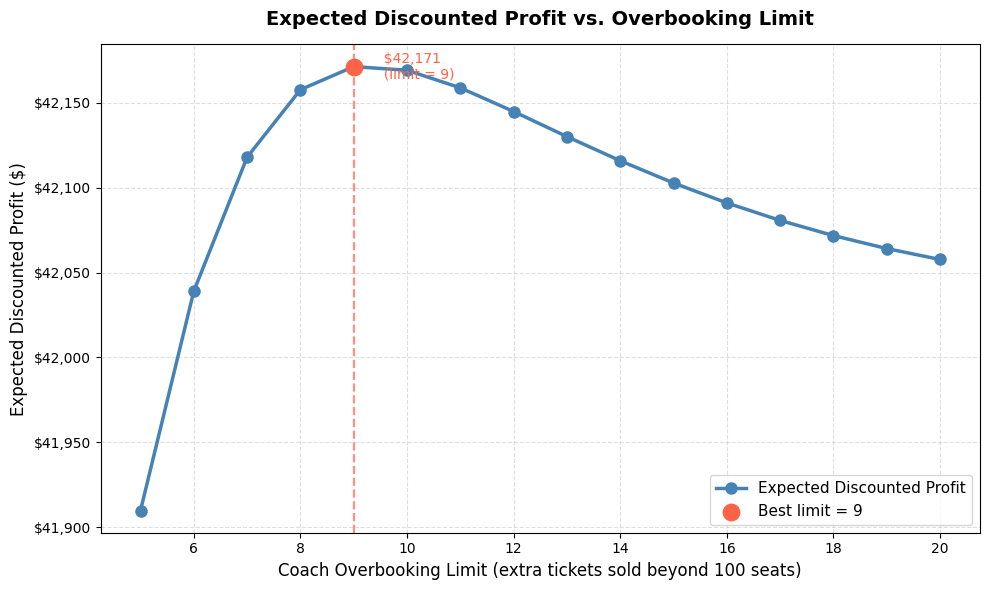


  Chart saved → overbooking_optimization.png

  Analysis complete.



In [9]:
# --------------------------------------------------
# SECTION 6: Main Execution Block
# --------------------------------------------------

def main():
    """
    Run the full Parts 1 and 2 analysis end-to-end.

    ── PART 1 ──────────────────────────────────────────────────────
    Establish a baseline by solving the DP with overbooking = 5.
    This tells us: what is the best we can do if we allow 5 extra
    coach tickets to be sold?

    ── PART 2 ──────────────────────────────────────────────────────
    Expand the search. Solve the DP for overbooking limits 5 through
    20. Identify the level that maximizes expected discounted profit,
    and produce a chart showing the full trade-off curve.

    ── RUNTIME NOTE ────────────────────────────────────────────────
    Each DP solve covers ~365 days × 121 coach states × 21 first-
    class states = ~930,000 states. With 16 runs for Part 2, expect
    this script to take several minutes. Progress is printed as each
    run advances.
    """

    print("\n" + "=" * 60)
    print("  MSBA Optimization 2  |  Project 2")
    print("  Airline Ticket Pricing via Dynamic Programming")
    print("=" * 60)

    # ── PART 1: Baseline with overbooking limit = 5 ─────────────
    print("\n  PART 1: Solving the DP with a fixed overbooking limit of 5.")
    print("  This is our benchmark — 5 seats beyond the 100-seat coach cabin.\n")

    baseline_profit = solve_dp(overbook_limit=5)

    print(f"\n  ┌─────────────────────────────────────────────┐")
    print(f"  │  PART 1 RESULT                              │")
    print(f"  │  Overbooking Limit    :  5 extra seats      │")
    print(f"  │  Expected Profit      : ${baseline_profit:>12,.2f}         │")
    print(f"  └─────────────────────────────────────────────┘")

    # ── PART 2: Optimize over limits 5 through 20 ───────────────
    print("\n  PART 2: Sweeping overbooking limits from 5 to 20.")
    print("  Each run is a full DP solve. This will take a few minutes.\n")

    results = find_best_overbooking_policy()

    print(f"\n  ┌─────────────────────────────────────────────┐")
    print(f"  │  PART 2 RESULT                              │")
    print(f"  │  Best Overbooking Limit : {results['best_limit']:>2} extra seats     │")
    print(f"  │  Best Expected Profit   : ${results['best_profit']:>12,.2f}         │")
    print(f"  └─────────────────────────────────────────────┘")

    plot_overbooking_results(results)

    print("\n  Analysis complete.\n")


if __name__ == "__main__":
    main()

# Task 3 and 4 (Flexible Policy & Sensitivity)

In [10]:
def solve_dp_flexible(max_coach=130):
    """
    Re-solve Policy 2 (No Sale, static demand) returning both the
    value table AND the optimal policy table.

    Identical to solve_dp_flexible() but also records the best
    (coach_price, first_price) at every state for the simulation.

    Returns
    -------
    value  : ndarray shape (SELLING_HORIZON+1, max_coach+1, max_first+1)
    policy : ndarray shape (SELLING_HORIZON+1, max_coach+1, max_first+1, 2)
             policy[t, cs, fs] = [optimal_coach_price, optimal_first_price]
    """
    max_first = FIRST_CAPACITY

    value  = np.zeros((SELLING_HORIZON + 1, max_coach + 1, max_first + 1))
    policy = np.zeros((SELLING_HORIZON + 1, max_coach + 1, max_first + 1, 2))

    coach_actions = [(300, 0.65), (325, 0.45), (350, 0.30), (0, 0.0)]
    first_actions = [(425, 0.08), (500, 0.04)]

    # Base case (t=0): departure day
    for cs in range(max_coach + 1):
        for fs in range(max_first + 1):
            value[0, cs, fs]  = -terminal_cost(cs, fs)
            policy[0, cs, fs] = [0, 0]

    # Backward induction
    for t in range(1, SELLING_HORIZON + 1):
        if t % 100 == 0 or t == SELLING_HORIZON:
            print(f'    [Policy 2 Solver] Day {t} / {SELLING_HORIZON} ...', end='\r')

        for cs in range(max_coach + 1):
            for fs in range(max_first + 1):

                best_ev          = -np.inf
                best_coach_price = 0
                best_first_price = 0

                for cp, cq in coach_actions:
                    for fp, fq in first_actions:

                        p_c = cq
                        if fs == max_first and cp > 0:
                            p_c = min(1.0, cq + FIRST_SOLD_OUT_COACH_BOOST)
                        p_f = fq

                        if cs >= max_coach: p_c = 0.0
                        if fs >= max_first: p_f = 0.0

                        v_none = value[t-1, cs, fs]
                        v_c    = value[t-1, min(cs+1, max_coach), fs]
                        v_f    = value[t-1, cs, min(fs+1, max_first)]
                        v_both = value[t-1, min(cs+1, max_coach), min(fs+1, max_first)]

                        ev = ( (1-p_c)*(1-p_f) * (DAILY_DISCOUNT * v_none)
                             +  p_c*(1-p_f)    * (cp + DAILY_DISCOUNT * v_c)
                             + (1-p_c)*p_f     * (fp + DAILY_DISCOUNT * v_f)
                             +  p_c*p_f        * (cp + fp + DAILY_DISCOUNT * v_both) )

                        if ev > best_ev:
                            best_ev          = ev
                            best_coach_price = cp
                            best_first_price = fp

                value[t, cs, fs]  = best_ev
                policy[t, cs, fs] = [best_coach_price, best_first_price]

    # print(f"    [Policy 2 Solver] Complete.{'':40}")
    return value, policy


In [11]:
def run_sensitivity_analysis(best_limit, multipliers):
    """
    Task 4: Re-solve the Part 2 DP with shifted demand probabilities.
    """
    results = []
    # Store original demand to restore after loop
    orig_coach = COACH_DEMAND.copy()
    orig_first = FIRST_DEMAND.copy()

    print(f"\n  {'Multiplier':>12} | {'Expected Profit':>18}")
    print("  " + "-" * 35)

    for m in multipliers:
        # Update Global Demands for the solver
        for p in COACH_DEMAND: COACH_DEMAND[p] = orig_coach[p] * m
        for p in FIRST_DEMAND: FIRST_DEMAND[p] = orig_first[p] * m

        # We use the best limit found in Step 2
        profit = solve_dp(best_limit)
        results.append((m, profit))
        print(f"  {m:>12.2f} | ${profit:>17,.2f}")

    # Restore original values
    for p in orig_coach: COACH_DEMAND[p] = orig_coach[p]
    for p in orig_first: FIRST_DEMAND[p] = orig_first[p]

    return results

In [12]:
def plot_task_4(sensitivity_results, baseline_profit: float = None): # Added baseline_profit parameter
    mults, profits = zip(*sensitivity_results)
    plt.figure(figsize=(10, 5))
    plt.plot(mults, profits, marker='D', color='darkred', linewidth=2)
    plt.title('Task 4: Sensitivity of Profit to Demand Fluctuations', fontweight='bold')
    plt.xlabel('Demand Multiplier (1.0 = Baseline)')
    plt.ylabel('Expected Profit ($)')
    plt.grid(True, alpha=0.3)
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

    if baseline_profit is not None:
        plt.axhline(y=baseline_profit, color='blue', linestyle='--', label=f'Task 2 Baseline (${baseline_profit:,.0f})')
        plt.legend()

    plt.show()

In [13]:
# Main Execution Block for the No Sale Policy

def main_2():

    print("\n" + "=" * 60)
    print("  MSBA Optimization 2  |  Project 2")
    print("  Airline Optimization: Tasks 3 and 4")
    print("=" * 60)

    # ── PART 3: Baseline with booking limit = 130 and No Sale Policy ─────────────
    print("\n  PART 3: Solving the DP with a fixed booking limit of 130 and No Sale Policy.")
    # print("  This is our benchmark — 5 seats beyond the 100-seat coach cabin.\n")

    # NOTE: solve_dp_flexible_with_policy also returns the policy table, but we only need value here.
    value, policy_table_placeholder = solve_dp_flexible(max_coach=130)

    no_sale_fixed_profit = value[SELLING_HORIZON, 0, 0]

    # We need a Task 2 result for comparison (using limit 15 as placeholder)
    task2_best_limit = 9
    task2_best_profit = solve_dp(task2_best_limit)

    print(f"\n  [Task 3 Result] Flexible Policy Profit: ${no_sale_fixed_profit:,.2f}")
    print(f"  [Comparison]    Hard Cap (9) Profit:  ${task2_best_profit:,.2f}")

    if no_sale_fixed_profit > task2_best_profit:
        print("  DECISION: Flexible Policy is SUPERIOR.")
    else:
        print("  DECISION: Hard Cap Policy is SUPERIOR.")


   # Run Task 4
    print("\n  TASK 4: Running Sensitivity Analysis on Sales Probabilities...")
    multipliers = [0.90, 0.95, 0.99, 1.0, 1.01, 1.05, 1.10]
    sens_results = run_sensitivity_analysis(task2_best_limit, multipliers)

    plot_task_4(sens_results, baseline_profit=task2_best_profit) # Passed baseline_profit here
    print("\n  Analysis Complete.")


  MSBA Optimization 2  |  Project 2
  Airline Optimization: Tasks 3 and 4

  PART 3: Solving the DP with a fixed booking limit of 130 and No Sale Policy.
  [overbook= 9]  Complete.                                                  

  [Task 3 Result] Flexible Policy Profit: $42,177.14
  [Comparison]    Hard Cap (9) Profit:  $42,171.35
  DECISION: Flexible Policy is SUPERIOR.

  TASK 4: Running Sensitivity Analysis on Sales Probabilities...

    Multiplier |    Expected Profit
  -----------------------------------
  [overbook= 9]  Complete.                                                  
          0.90 | $        41,429.97
  [overbook= 9]  Complete.                                                  
          0.95 | $        41,815.54
  [overbook= 9]  Complete.                                                  
          0.99 | $        42,102.34
  [overbook= 9]  Complete.                                                  
          1.00 | $        42,171.35
  [overbook= 9]  Complete.   

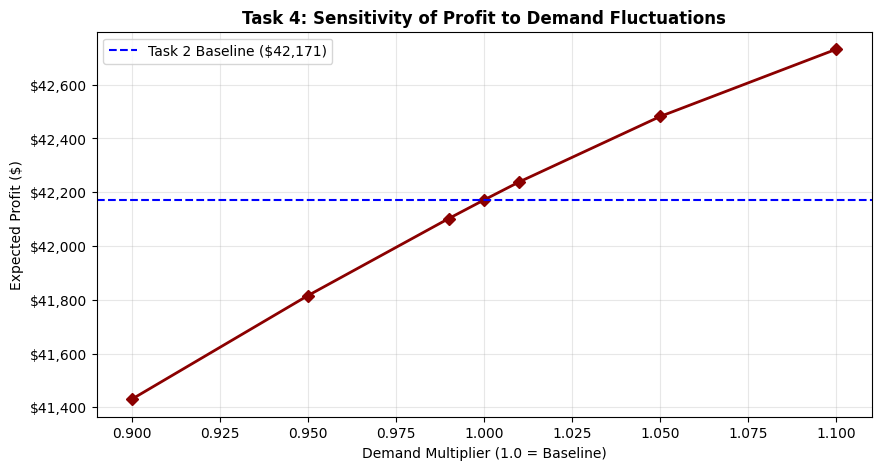


  Analysis Complete.


In [14]:
main_2()

# Part 5 - Change to Dynamic Demand

Solve the DP with dynamic demand (demand increases as time increases i.e. the closer we are to take off). Below is solving the problem WITHOUT the no sale policy from task 3.


  Airline Ticket Pricing via Dynamic Programming

  PART 3: Sweeping overbooking limits from 5 to 20 with Dynamic Demand.
  Each run is a full DP solve. This will take a few minutes.
  The demand probabilities are adjusted based on time elapsed.

  PART 5 — Searching for the Optimal Overbooking Policy with Dynamic Demand

    Overbook Limit  |     Expected Profit
  ------------------------------------------
  [dynamic_demand_overbook= 5]  Complete.                                                  
                 5  |  $        41,599.27
  [dynamic_demand_overbook= 6]  Complete.                                                  
                 6  |  $        41,727.52
  [dynamic_demand_overbook= 7]  Complete.                                                  
                 7  |  $        41,804.96
  [dynamic_demand_overbook= 8]  Complete.                                                  
                 8  |  $        41,844.15
  [dynamic_demand_overbook= 9]  Complete.           

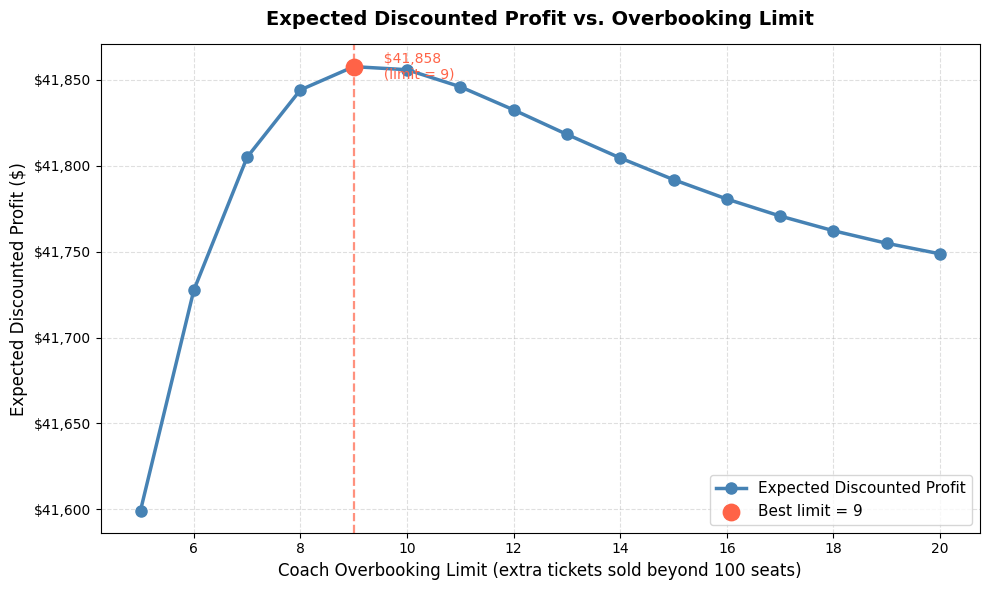


  Chart saved → overbooking_optimization.png

  Analysis complete for dynamic demand.



In [15]:
def solve_dp_dynamic_demand(overbook_limit: int) -> float:
    """
    Solve the airline pricing problem via backward-induction DP with dynamic demand.

    The demand probabilities are adjusted by a factor based on `t_elapsed` (days tickets have been on sale).

    Parameters
    ----------
    overbook_limit : int
        Number of coach tickets the airline is willing to sell
        beyond the physical 100-seat capacity.

    Returns
    -------
    float
        The maximum expected discounted profit, starting from
        day 365 with zero tickets sold in either cabin.
    """

    max_coach_tickets = COACH_CAPACITY + overbook_limit
    max_first_tickets = FIRST_CAPACITY

    value = np.zeros(
        (SELLING_HORIZON + 1, max_coach_tickets + 1, max_first_tickets + 1)
    )

    print(f"  [dynamic_demand_overbook={overbook_limit:>2}]  Precomputing departure-day costs ...",
          end="\r")

    for cs in range(max_coach_tickets + 1):
        for fs in range(max_first_tickets + 1):
            value[0, cs, fs] = -terminal_cost(cs, fs)

    for t in range(1, SELLING_HORIZON + 1):

        if t % 73 == 0 or t == SELLING_HORIZON:
            pct = int(100 * t / SELLING_HORIZON)
            print(f"  [dynamic_demand_overbook={overbook_limit:>2}]  Day {t:>3} / {SELLING_HORIZON}  ({pct}%) ...",
                  end="\r")

        # Calculate the number of days tickets have been on sale
        t_elapsed = SELLING_HORIZON - t
        demand_factor = 0.75 + (t_elapsed / 730)

        for cs in range(max_coach_tickets + 1):
            for fs in range(max_first_tickets + 1):

                can_sell_coach = (cs < max_coach_tickets)
                can_sell_first = (fs < max_first_tickets)

                first_class_is_full = not can_sell_first

                next_cs = (cs + 1) if can_sell_coach else cs
                next_fs = (fs + 1) if can_sell_first else fs

                best_expected_profit = -np.inf

                for coach_price in COACH_PRICES:
                    for first_price in FIRST_PRICES:

                        # Start with the base demand probabilities
                        base_p_coach = COACH_DEMAND[coach_price]
                        base_p_first = FIRST_DEMAND[first_price]

                        # Apply dynamic demand factor
                        p_coach = min(1.0, base_p_coach * demand_factor)
                        p_first = min(1.0, base_p_first * demand_factor)

                        # Apply spillover boost when first-class is sold out
                        if first_class_is_full:
                            p_coach = min(1.0, p_coach + FIRST_SOLD_OUT_COACH_BOOST)

                        # A full cabin cannot generate a sale, regardless of price
                        if not can_sell_coach:
                            p_coach = 0.0
                        if not can_sell_first:
                            p_first = 0.0

                        prob_no_sale = (1 - p_coach) * (1 - p_first)
                        val_no_sale  = (DAILY_DISCOUNT
                                        * value[t - 1, cs, fs])

                        prob_coach_only = p_coach * (1 - p_first)
                        val_coach_only  = (coach_price
                                           + DAILY_DISCOUNT
                                           * value[t - 1, next_cs, fs])

                        prob_first_only = (1 - p_coach) * p_first
                        val_first_only  = (first_price
                                           + DAILY_DISCOUNT
                                           * value[t - 1, cs, next_fs])

                        prob_both_sold = p_coach * p_first
                        val_both_sold  = (coach_price + first_price
                                          + DAILY_DISCOUNT
                                          * value[t - 1, next_cs, next_fs])

                        expected_profit = (prob_no_sale    * val_no_sale
                                         + prob_coach_only * val_coach_only
                                         + prob_first_only * val_first_only
                                         + prob_both_sold  * val_both_sold)

                        if expected_profit > best_expected_profit:
                            best_expected_profit = expected_profit

                value[t, cs, fs] = best_expected_profit

    print(f"  [dynamic_demand_overbook={overbook_limit:>2}]  Complete.{' ' * 50}")

    return value[SELLING_HORIZON, 0, 0]

def find_best_overbooking_policy_dynamic_demand() -> dict:
    """
    Compare overbooking policies for dynamic demand by solving the DP for limits 5 to 20.

    Returns
    -------
    dict with keys:
        'limits'      — list of overbooking limits tested
        'profits'     — expected profit for each limit
        'best_limit'  — the limit that produced the highest profit
        'best_profit' — the corresponding expected profit
    """

    overbook_limits  = list(range(5, 21))
    expected_profits = []

    print("\n" + "=" * 60)
    print("  PART 5 — Searching for the Optimal Overbooking Policy with Dynamic Demand")
    print("=" * 60)
    print(f"\n  {'Overbook Limit':>16}  |  {'Expected Profit':>18}")
    print("  " + "-" * 42)

    for limit in overbook_limits:
        profit = solve_dp_dynamic_demand(limit)
        expected_profits.append(profit)
        print(f"  {limit:>16}  |  ${profit:>17,.2f}")

    print("  " + "=" * 42)

    best_index  = int(np.argmax(expected_profits))
    best_limit  = overbook_limits[best_index]
    best_profit = expected_profits[best_index]

    return {
        'limits':      overbook_limits,
        'profits':     expected_profits,
        'best_limit':  best_limit,
        'best_profit': best_profit,
    }

def main_dynamic_demand():
    """
    Run the dynamic demand analysis end-to-end.
    """

    print("\n" + "=" * 60)
    print("  Airline Ticket Pricing via Dynamic Programming")
    print("=" * 60)

    # ── PART 3: Optimize over limits 5 through 20 with dynamic demand ───────
    print("\n  PART 3: Sweeping overbooking limits from 5 to 20 with Dynamic Demand.")
    print("  Each run is a full DP solve. This will take a few minutes.")
    print("  The demand probabilities are adjusted based on time elapsed.")

    results_dynamic_demand = find_best_overbooking_policy_dynamic_demand()

    print(f"\n  ┌─────────────────────────────────────────────┐")
    print(f"  │  PART 5 RESULT (Dynamic Demand)             │")
    print(f"  │  Best Overbooking Limit : {results_dynamic_demand['best_limit']:>2} extra seats     │")
    print(f"  │  Best Expected Profit   : ${results_dynamic_demand['best_profit']:>12,.2f}         │")
    print(f"  └─────────────────────────────────────────────┘")

    plot_overbooking_results(results_dynamic_demand)

    print("\n  Analysis complete for dynamic demand.\n")

if __name__ == "__main__":
    main_dynamic_demand()

Solve the DP with dynamic demand WITH the no sale policy from task 3

In [16]:
def solve_dp_flexible_dynamic_demand(max_coach: int = 130) -> float:
    """
    Solve the airline pricing DP with:
      1. A 'No Sale' option for coach (Task 3 / Part 3 addition).
      2. Dynamic demand — the sale probability is scaled by
         (0.75 + t_elapsed / 730) where t_elapsed = SELLING_HORIZON - t.

    Parameters
    ----------
    max_coach : int
        Hard cap on coach tickets (default 130, matching Task 3).

    Returns
    -------
    float
        Maximum expected discounted profit starting from
        day 365 with zero tickets sold in either cabin.
    """

    max_first = FIRST_CAPACITY

    # value[t, coach_sold, first_sold]
    value = np.zeros((SELLING_HORIZON + 1, max_coach + 1, max_first + 1))
    policy = np.zeros((SELLING_HORIZON + 1, max_coach + 1, max_first + 1, 2))

    coach_actions = [(300, 0.65), (325, 0.45), (350, 0.30), (0, 0.0)]
    first_actions = [(425, 0.08), (500, 0.04)]

    # ------------------------------------------------------------------
    # Base case (t = 0): departure day — only overbooking costs matter.
    # Identical to every other DP variant.
    # ------------------------------------------------------------------
    for cs in range(max_coach + 1):
        for fs in range(max_first + 1):
            value[0, cs, fs] = -terminal_cost(cs, fs)
            policy[0, cs, fs] = [0, 0]

# ------------------------------------------------------------------
    # Backward induction: day 1 → day 365
    # ------------------------------------------------------------------
    for t in range(1, SELLING_HORIZON + 1):

        if t % 100 == 0 or t == SELLING_HORIZON:
            print(f"    [Flexible + Dynamic Demand] Processing Day {t} ...", end="\r")

        # ── Dynamic demand factor for this day ─────────────────────────
        # t_elapsed is the number of days since tickets first went on sale.
        # When t = SELLING_HORIZON (day 1 of sales), t_elapsed = 0.
        # When t = 1 (day before departure), t_elapsed = 364.
        t_elapsed = SELLING_HORIZON - t
        demand_factor = 0.75 + (t_elapsed / 730)

        for cs in range(max_coach + 1):
            for fs in range(max_first + 1):

                # ── Available coach actions (Task 3: include No Sale) ───
                # Each entry is (price_dollars, base_probability).
                # The No Sale action has price 0 and probability 0 —
                # the dynamic factor multiplied by 0 is still 0, so no
                # special-casing is needed.
                coach_actions = [
                    (300, 0.65),
                    (325, 0.45),
                    (350, 0.30),
                    (0,   0.0),   # ← No Sale option (Task 3)
                ]
                first_actions = [
                    (425, 0.08),
                    (500, 0.04),
                ]

                best_ev = -np.inf
                best_coach_price = 0
                best_first_price = 0

                for cp, base_cq in coach_actions:
                    for fp, base_fq in first_actions:
                      # ── Apply dynamic demand factor ─────────────────
                        # Scale each base probability, then clamp to [0, 1].
                        p_c = min(1.0, base_cq * demand_factor)
                        p_f = min(1.0, base_fq * demand_factor)

                        # ── First-class sold-out spillover (Task 3 logic) ─
                        # When first-class is full AND the airline is
                        # actively pricing coach (cp > 0), add the 4 pp
                        # spillover boost to the already-scaled coach prob.
                        if fs == max_first and cp > 0:
                            p_c = min(1.0, p_c + FIRST_SOLD_OUT_COACH_BOOST)

                        # ── Boundary checks ─────────────────────────────
                        # A full cabin cannot generate a sale.
                        if cs >= max_coach:
                            p_c = 0.0
                        if fs >= max_first:
                            p_f = 0.0

                        # ── Next states (with boundary protection) ──────
                        v_none = value[t - 1, cs, fs]
                        v_c    = value[t - 1, min(cs + 1, max_coach), fs]
                        v_f    = value[t - 1, cs, min(fs + 1, max_first)]
                        v_both = value[t - 1,
                                       min(cs + 1, max_coach),
                                       min(fs + 1, max_first)]

                        # ── Bellman update (four mutually exclusive outcomes) ─
                        ev = (
                            (1 - p_c) * (1 - p_f) * (DAILY_DISCOUNT * v_none)
                          + p_c       * (1 - p_f) * (cp + DAILY_DISCOUNT * v_c)
                          + (1 - p_c) * p_f       * (fp + DAILY_DISCOUNT * v_f)
                          + p_c       * p_f       * (cp + fp + DAILY_DISCOUNT * v_both)
                        )

                        if ev > best_ev:
                            best_ev = ev
                            best_coach_price = cp
                            best_first_price = fp

                value[t, cs, fs] = best_ev
                policy[t, cs, fs] = [best_coach_price, best_first_price]


    print(f"    [Flexible + Dynamic Demand] Complete.{' ' * 50}")
    return value, policy



In [18]:
def main_part5_no_sale():
    """
    Run Part 5 with the No Sale policy and dynamic demand,
    then compare against the static flexible-demand baseline
    (solve_dp_flexible from Task 3).
    """

    print("\n" + "=" * 60)
    print("  PART 5 — Dynamic Demand WITH No Sale Policy")
    print("=" * 60)

    print("\n  Solving DP: flexible 'No Sale' policy + dynamic demand ...")
    value, policy = solve_dp_flexible_dynamic_demand(max_coach=130)
    dynamic_no_sale_profit = value[SELLING_HORIZON, 0, 0]

    print(f"\n  Solving comparison baseline: Task 3 flexible (static demand) ...")
    value, policy_table_placeholder = solve_dp_flexible(max_coach=130)

    no_sale_fixed_profit = value[SELLING_HORIZON, 0, 0]

    print(f"\n  ┌──────────────────────────────────────────────────────┐")
    print(f"  │  PART 5 — No Sale + Dynamic Demand  RESULTS         │")
    print(f"  │                                                      │")
    print(f"  │  Dynamic demand  + No Sale profit: ${dynamic_no_sale_profit:>12,.2f}   │")
    print(f"  │  Static  demand  + No Sale profit: ${no_sale_fixed_profit:>12,.2f}   │")
    print(f"  │                                                      │")

    diff = dynamic_no_sale_profit - no_sale_fixed_profit
    direction = "higher" if diff >= 0 else "lower"
    print(f"  │  Dynamic is ${abs(diff):,.2f} {direction} than static.        │")
    print(f"  └──────────────────────────────────────────────────────┘")
    print("\n  Analysis complete.\n")


if __name__ == "__main__":
    main_part5_no_sale()




  PART 5 — Dynamic Demand WITH No Sale Policy

  Solving DP: flexible 'No Sale' policy + dynamic demand ...
    [Flexible + Dynamic Demand] Complete.                                                  

  Solving comparison baseline: Task 3 flexible (static demand) ...
    [Policy 2 Solver] Day 365 / 365 ...
  ┌──────────────────────────────────────────────────────┐
  │  PART 5 — No Sale + Dynamic Demand  RESULTS         │
  │                                                      │
  │  Dynamic demand  + No Sale profit: $   41,863.83   │
  │  Static  demand  + No Sale profit: $   42,177.14   │
  │                                                      │
  │  Dynamic is $313.31 lower than static.        │
  └──────────────────────────────────────────────────────┘

  Analysis complete.



# Task 6

Compare all policies to find the optimal one

In [19]:
# ==============================================================
# POLICY COMPARISON — All 4 Overbooking Policies
# ==============================================================
#
# Policy 1: Standard DP, static demand           (solve_dp)           — sweep 5-20
# Policy 2: Flexible No Sale, static demand      (solve_dp_flexible)   — fixed cap 130
# Policy 3: Standard DP, dynamic demand          (solve_dp_dynamic_demand) — sweep 5-20
# Policy 4: Flexible No Sale, dynamic demand     (solve_dp_flexible_dynamic_demand) — fixed cap 130
# ==============================================================

def compare_all_policies():
    """
    Solve all four pricing/booking policies and report the best
    overbooking limit and expected profit for each.

    Policies 1 and 3 sweep overbooking limits 5-20 and take the best.
    Policies 2 and 4 use a fixed cap of 130 (No Sale policies) and are solved once.

    Returns
    -------
    dict
        Keys are policy names; values are dicts with
        'best_limit' and 'best_profit'.
    """

    overbook_limits = list(range(5, 21))  # 5, 6, ..., 20

    summary = {}

    print("\n" + "=" * 70)
    print("  POLICY COMPARISON — Best Overbooking Limit per Policy")
    print("=" * 70)

    # ------------------------------------------------------------------
    # Policies 1 and 3 — sweep overbooking limits 5 to 20
    # ------------------------------------------------------------------
    sweep_policies = {
        "Policy 1: Standard DP (static demand)":  solve_dp,
        "Policy 3: Standard DP (dynamic demand)": solve_dp_dynamic_demand,
    }

    for policy_name, solver_fn in sweep_policies.items():

        print(f"\n  -- {policy_name} --")
        print(f"  {'Overbook Limit':>16}  |  {'Expected Profit':>18}")
        print("  " + "-" * 42)

        profits = []
        for limit in overbook_limits:
            profit = solver_fn(limit)
            profits.append(profit)
            print(f"  {limit:>16}  |  ${profit:>17,.2f}")

        best_idx    = int(np.argmax(profits))
        best_limit  = overbook_limits[best_idx]
        best_profit = profits[best_idx]

        print("  " + "=" * 42)
        print(f"  Best limit: {best_limit}  |  Best profit: ${best_profit:,.2f}")

        summary[policy_name] = {
            "best_limit":  best_limit,
            "best_profit": best_profit,
            "all_limits":  overbook_limits,
            "all_profits": profits,
        }

    # ------------------------------------------------------------------
    # Policies 2 and 4 — No Sale policies, fixed cap of 130, solved once
    # ------------------------------------------------------------------
    fixed_policies = {
        "Policy 2: No Sale (static demand)":  solve_dp_flexible,
        "Policy 4: No Sale (dynamic demand)": solve_dp_flexible_dynamic_demand,
    }

    for policy_name, solver_fn in fixed_policies.items():
        print(f"\n  -- {policy_name} --")
        print("  (Fixed cap of 130 — solved once, no overbooking sweep)")

        value, policy = solver_fn(max_coach=130)
        profit = value[SELLING_HORIZON, 0, 0]
        print(f"  Expected Profit: ${profit:,.2f}")

        summary[policy_name] = {
            "best_limit":  "N/A (cap=130)",
            "best_profit": profit,
            "all_limits":  None,
            "all_profits": None,
        }

    # ------------------------------------------------------------------
    # Final ranking
    # ------------------------------------------------------------------
    print("\n\n" + "=" * 70)
    print("  FINAL RANKING — All Policies by Expected Profit")
    print("=" * 70)
    print(f"\n  {'Policy':<42}  {'Best Limit':>14}  {'Expected Profit':>18}")
    print("  " + "-" * 78)

    ranked = sorted(summary.items(), key=lambda x: x[1]["best_profit"], reverse=True)

    for rank, (name, res) in enumerate(ranked, start=1):
        limit_str = str(res["best_limit"])
        print(f"  #{rank}  {name:<42}  {limit_str:>14}  ${res['best_profit']:>17,.2f}")

    print("\n  " + "=" * 78)
    winner_name, winner_res = ranked[0]
    print(f"\n  BEST POLICY : {winner_name}")
    print(f"  Best Limit  : {winner_res['best_limit']}")
    print(f"  Best Profit : ${winner_res['best_profit']:,.2f}")
    print()

    return summary


In [21]:
def plot_policy_comparison(summary: dict) -> None:
    """
    Plot expected profit vs. overbooking limit for all four policies.
    Policies 1 and 3 are shown as curves (they sweep limits 5-20).
    Policies 2 and 4 are shown as horizontal dashed lines (fixed cap of 130).
    """

    fig, ax = plt.subplots(figsize=(11, 6))

    sweep_colors  = {
        "Policy 1: Standard DP (static demand)":  ("steelblue",  "o"),
        "Policy 3: Standard DP (dynamic demand)": ("seagreen",   "s"),
    }
    fixed_colors  = {
        "Policy 2: No Sale (static demand)":  "crimson",
        "Policy 4: No Sale (dynamic demand)": "darkorange",
    }

    # Sweep policies — lines with best point marked
    for name, (color, marker) in sweep_colors.items():
        res = summary[name]
        ax.plot(
            res["all_limits"], res["all_profits"],
            marker=marker, markersize=7, linewidth=2.2,
            color=color, label=name,
        )
        ax.scatter(
            [res["best_limit"]], [res["best_profit"]],
            color=color, s=120, zorder=6, edgecolors="black", linewidths=0.8,
        )

    # Fixed-cap policies — horizontal dashed lines
    for name, color in fixed_colors.items():
        res = summary[name]
        ax.axhline(
            y=res["best_profit"],
            color=color, linestyle="--", linewidth=1.8,
            label=f"{name}  (${res['best_profit']:,.0f})",
        )

    ax.set_title(
        "Expected Discounted Profit vs. Overbooking Limit\nAll Four Policies",
        fontsize=14, fontweight="bold", pad=14,
    )
    ax.set_xlabel(
        "Coach Overbooking Limit (extra tickets beyond 100 seats)\n(Policies 2 & 4 use fixed cap of 130)",
        fontsize=12,
    )
    ax.set_ylabel("Expected Discounted Profit ($)", fontsize=12)
    ax.legend(fontsize=10, loc="lower right")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda val, _: f"${val:,.0f}")
    )

    plt.tight_layout()
    plt.savefig("policy_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  Chart saved -> policy_comparison.png")



  POLICY COMPARISON — Best Overbooking Limit per Policy

  -- Policy 1: Standard DP (static demand) --
    Overbook Limit  |     Expected Profit
  ------------------------------------------
  [overbook= 5]  Complete.                                                  
                 5  |  $        41,909.75
  [overbook= 6]  Complete.                                                  
                 6  |  $        42,039.02
  [overbook= 7]  Complete.                                                  
                 7  |  $        42,117.95
  [overbook= 8]  Complete.                                                  
                 8  |  $        42,157.77
  [overbook= 9]  Complete.                                                  
                 9  |  $        42,171.35
  [overbook=10]  Complete.                                                  
                10  |  $        42,169.24
  [overbook=11]  Complete.                                                  
                11

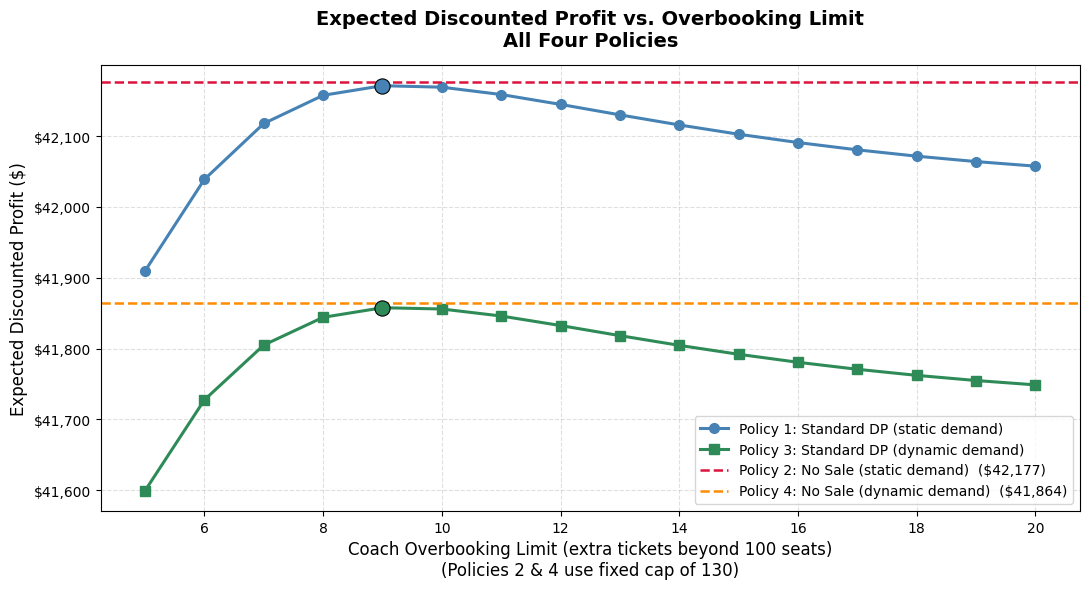

  Chart saved -> policy_comparison.png


In [22]:
summary = compare_all_policies()
plot_policy_comparison(summary)

The best policy from our analyses is Policy 2: the No Sale policy with static demand. We will now implement this policy going forward.

## Simulate going forward with Policy 2 (No Sale with Static Demand)

In [23]:
def simulate_policy2(policy, max_coach=130, seed=None):
    """
    Simulate one 365-day selling season using the Policy 2 pricing table.

    Each day (t counting down from 365 to 1):
      1. Look up optimal (coach_price, first_price) from policy table.
      2. Determine sale probabilities for each cabin.
      3. Draw Bernoulli random variables to simulate sales.
      4. Update state and accumulate discounted revenue.

    Parameters
    ----------
    policy   : ndarray -- optimal action table from solve_dp_flexible_with_policy()
    max_coach: int     -- hard cap on coach tickets (default 130)
    seed     : int     -- random seed for reproducibility

    Returns
    -------
    dict with keys:
        'total_revenue'      -- total discounted revenue over the season
        'coach_sold'         -- final coach tickets sold
        'first_sold'         -- final first-class tickets sold
        'coach_price_vec'    -- coach price each day (0 = No Sale)
        'first_price_vec'    -- first-class price each day
        'coach_sold_vec'     -- cumulative coach tickets sold each day
        'first_sold_vec'     -- cumulative first-class tickets sold each day
        'revenue_vec'        -- cumulative discounted revenue each day
    """
    if seed is not None:
        np.random.seed(seed)

    max_first = FIRST_CAPACITY

    # State: tickets sold so far
    cs = 0  # coach tickets sold
    fs = 0  # first-class tickets sold

    total_revenue = 0.0

    # Storage vectors (one entry per selling day)
    coach_price_vec = np.zeros(SELLING_HORIZON)
    first_price_vec = np.zeros(SELLING_HORIZON)
    coach_sold_vec  = np.zeros(SELLING_HORIZON)
    first_sold_vec  = np.zeros(SELLING_HORIZON)
    revenue_vec     = np.zeros(SELLING_HORIZON)

    # t counts DOWN from SELLING_HORIZON to 1 (days remaining until departure)
    # day_idx counts UP from 0 to index into storage vectors
    for day_idx, t in enumerate(range(SELLING_HORIZON, 0, -1)):

        # Look up optimal prices for current state
        opt_coach_price = int(policy[t, cs, fs, 0])
        opt_first_price = int(policy[t, cs, fs, 1])

        coach_price_vec[day_idx] = opt_coach_price
        first_price_vec[day_idx] = opt_first_price

        # Determine sale probabilities
        if opt_coach_price == 0 or cs >= max_coach:
            p_c = 0.0
        else:
            p_c = COACH_DEMAND[opt_coach_price]
            if fs >= max_first:  # first-class sold-out spillover
                p_c = min(1.0, p_c + FIRST_SOLD_OUT_COACH_BOOST)

        p_f = 0.0 if fs >= max_first else FIRST_DEMAND[opt_first_price]

        # Simulate sales (Bernoulli draws) -- mirrors template structure
        coach_sale = int(np.random.random() < p_c)
        first_sale = int(np.random.random() < p_f)

        # Update state
        cs += coach_sale
        fs += first_sale

        # Accumulate discounted revenue (day_idx=0 is first selling day)
        discount    = DAILY_DISCOUNT ** day_idx
        day_revenue = (coach_sale * opt_coach_price +
                       first_sale * opt_first_price) * discount
        total_revenue += day_revenue

        # Save results
        coach_sold_vec[day_idx] = cs
        first_sold_vec[day_idx] = fs
        revenue_vec[day_idx]    = total_revenue

    return {
        'total_revenue':   total_revenue,
        'coach_sold':      cs,
        'first_sold':      fs,
        'coach_price_vec': coach_price_vec,
        'first_price_vec': first_price_vec,
        'coach_sold_vec':  coach_sold_vec,
        'first_sold_vec':  first_sold_vec,
        'revenue_vec':     revenue_vec,
    }


In [24]:
def plot_simulation(results: dict) -> None:
    """
    Four-panel plot summarising one simulated selling season:
      1. Coach price each day
      2. First-class price each day
      3. Cumulative tickets sold (both cabins)
      4. Cumulative discounted revenue
    """
    days = np.arange(1, SELLING_HORIZON + 1)

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle(
        'Policy 2 Simulation — One Selling Season (365 Days)',
        fontsize=14, fontweight='bold', y=1.01
    )

    # Panel 1 — Coach price
    ax = axes[0, 0]
    ax.step(days, results['coach_price_vec'], color='steelblue', linewidth=1.5)
    ax.set_title('Coach Price per Day')
    ax.set_xlabel('Day of Selling Season')
    ax.set_ylabel('Price ($)')
    ax.set_yticks([0, 300, 325, 350])
    ax.set_yticklabels(['No Sale', '$300', '$325', '$350'])
    ax.grid(True, alpha=0.3)

    # Panel 2 — First-class price
    ax = axes[0, 1]
    ax.step(days, results['first_price_vec'], color='seagreen', linewidth=1.5)
    ax.set_title('First-Class Price per Day')
    ax.set_xlabel('Day of Selling Season')
    ax.set_ylabel('Price ($)')
    ax.set_yticks([425, 500])
    ax.set_yticklabels(['$425', '$500'])
    ax.grid(True, alpha=0.3)

    # Panel 3 — Cumulative tickets sold
    ax = axes[1, 0]
    ax.plot(days, results['coach_sold_vec'], color='steelblue', label='Coach',       linewidth=1.8)
    ax.plot(days, results['first_sold_vec'], color='seagreen',  label='First Class', linewidth=1.8)
    ax.axhline(y=COACH_CAPACITY, color='steelblue', linestyle='--', alpha=0.5, label='Coach capacity (100)')
    ax.axhline(y=FIRST_CAPACITY, color='seagreen',  linestyle='--', alpha=0.5, label='First capacity (20)')
    ax.set_title('Cumulative Tickets Sold')
    ax.set_xlabel('Day of Selling Season')
    ax.set_ylabel('Tickets Sold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Panel 4 — Cumulative discounted revenue
    ax = axes[1, 1]
    ax.plot(days, results['revenue_vec'], color='darkorange', linewidth=1.8)
    ax.set_title('Cumulative Discounted Revenue')
    ax.set_xlabel('Day of Selling Season')
    ax.set_ylabel('Revenue ($)')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('simulation_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('  Chart saved -> simulation_results.png')


Solving Policy 2 DP to extract optimal pricing policy ...
Expected profit (from DP): $42,177.14

Running simulation ...

  Simulated Season Summary
  Total discounted revenue : $   43,066.05
  Coach tickets sold       :          110
  First-class tickets sold :           18


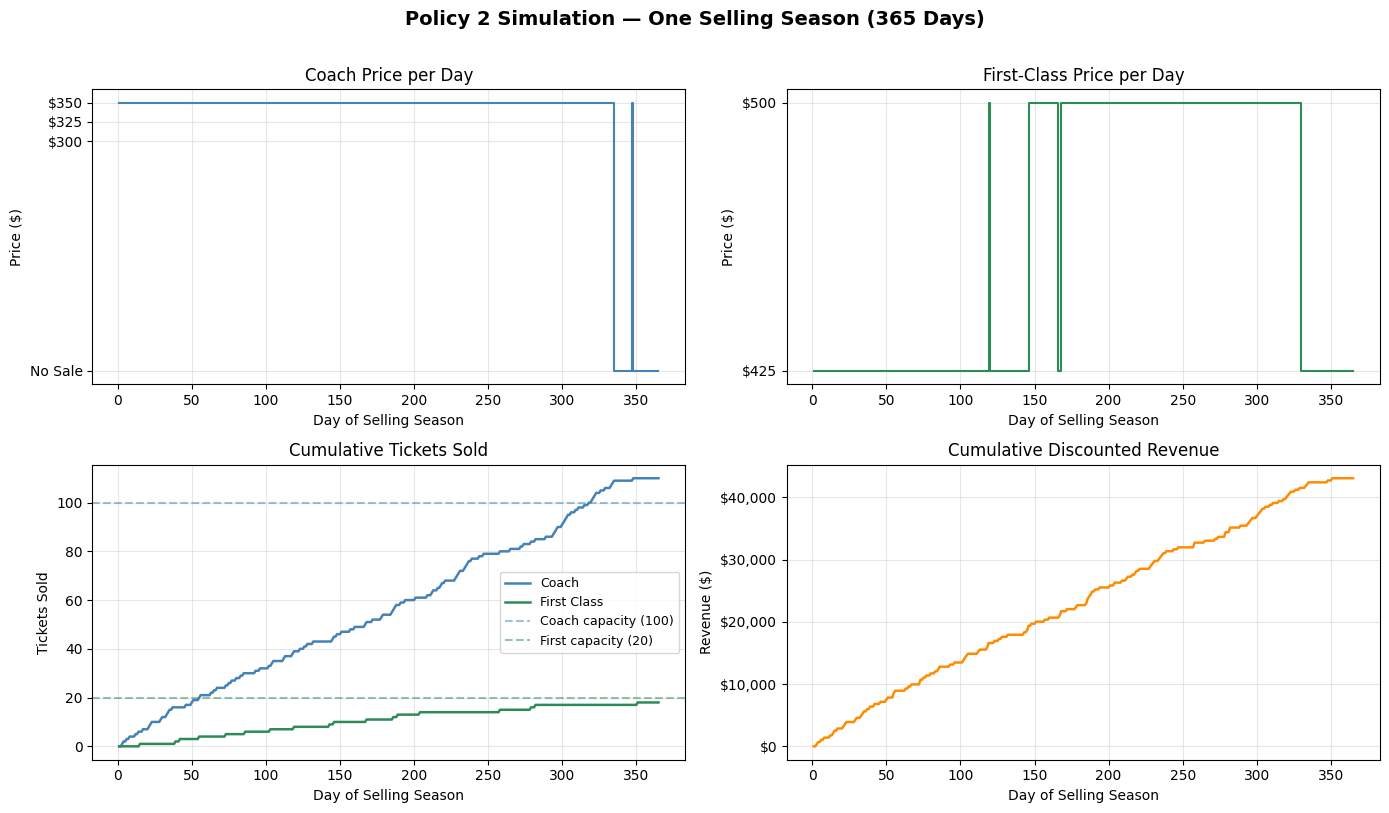

  Chart saved -> simulation_results.png


In [25]:
# Step 1: Solve the DP and extract the optimal policy table
print('Solving Policy 2 DP to extract optimal pricing policy ...')
value_table, policy_table = solve_dp_flexible(max_coach=130)
print(f"Expected profit (from DP): ${value_table[SELLING_HORIZON, 0, 0]:,.2f}")

# Step 2: Run one simulated selling season
print('\nRunning simulation ...')
sim_results = simulate_policy2(policy_table, max_coach=130, seed=42)

print(f"\n  Simulated Season Summary")
print(f"  {'='*35}")
print(f"  Total discounted revenue : ${sim_results['total_revenue']:>12,.2f}")
print(f"  Coach tickets sold       : {sim_results['coach_sold']:>12}")
print(f"  First-class tickets sold : {sim_results['first_sold']:>12}")

# Step 3: Plot the results
plot_simulation(sim_results)


In [26]:
# ── Helper: does this (cs, fs) state have nonzero probability of denied boarding? ──
# (defined before the loop — shown here for clarity, move above the loop in practice)
def any_denial_possible(c, f):
    """Return True if there is ANY (x_c, x_f) outcome where passengers are denied boarding."""
    if c <= COACH_CAPACITY:
        return False   # can't exceed coach capacity
    # Maximum FC buffer: seats not taken by FC arrivals (best case: fs=0 shows, leaving FC_CAPACITY seats)
    # Worst case for denial: x_c = c (all show up), x_f = f (all show up, no empty FC seats)
    # But we just need *any* positive-probability outcome with bump_off > 0.
    # bump_off > 0  iff  x_c - COACH_CAPACITY > FIRST_CAPACITY - x_f
    # i.e.  x_c + x_f > COACH_CAPACITY + FIRST_CAPACITY
    # Minimum x_c + x_f with positive probability: both could be 0... but x_c >= 0
    # We need x_c > COACH_CAPACITY (requires c > COACH_CAPACITY) AND x_c - COACH_CAPACITY > FIRST_CAPACITY - x_f
    # Easiest check: if c > COACH_CAPACITY, the max possible bump_up is FIRST_CAPACITY (if x_f=0).
    # If c - COACH_CAPACITY > FIRST_CAPACITY, denial is guaranteed regardless of FC show-ups.
    # Otherwise, it's possible only if x_f is high enough. We use a direct probability check.
    for x_c in range(COACH_CAPACITY + 1, c + 1):   # x_c must exceed coach capacity
        for x_f in range(f + 1):
            empty_fc  = FIRST_CAPACITY - x_f
            bump_off  = max(0, (x_c - COACH_CAPACITY) - empty_fc)
            if bump_off > 0:
                return True
    return False



In [27]:
# ── Monte Carlo: 5,000 simulations of Policy 2 ─────────────────────────────

N_SIM = 5_000

# Storage across simulations
all_profits        = np.zeros(N_SIM)   # discounted profit = revenue - discounted ob cost
all_revenues       = np.zeros(N_SIM)   # discounted revenue only
all_ob_costs       = np.zeros(N_SIM)   # expected overbooking cost (undiscounted)
all_coach_sold     = np.zeros(N_SIM, dtype=int)
all_first_sold     = np.zeros(N_SIM, dtype=int)
coach_overbooked   = np.zeros(N_SIM, dtype=bool)  # True if coach tickets sold > COACH_CAPACITY
denied_boarding    = np.zeros(N_SIM, dtype=bool)  # True if any pax bumped OFF the plane
all_bumped_up = np.zeros(N_SIM, dtype=int)   # bumped up to first-class
all_denied    = np.zeros(N_SIM, dtype=int)   # bumped off the plane entirely

for sim in range(N_SIM):
    result = simulate_policy2(policy_table, max_coach=130, seed=sim)

    cs = result['coach_sold']
    fs = result['first_sold']
    rev = result['total_revenue']

    # ── Analytical overbooking cost via binomial PMF ──────────────────────
    ob_cost = terminal_cost(cs, fs)   # reuse function from earlier

    # Simulate actual show-ups for this flight
    coach_arrivals = np.random.binomial(cs, COACH_SHOW_UP_PROB)
    first_arrivals = np.random.binomial(fs, FIRST_SHOW_UP_PROB)

    coach_excess = max(0, coach_arrivals - COACH_CAPACITY)
    open_first   = max(0, FIRST_CAPACITY - first_arrivals)
    bumped_up    = min(coach_excess, open_first)
    denied       = coach_excess - bumped_up

    all_bumped_up[sim] = bumped_up
    all_denied[sim]    = denied

    discounted_ob_cost = ob_cost * DAILY_DISCOUNT ** SELLING_HORIZON
    profit = rev - discounted_ob_cost

    all_revenues[sim]   = rev
    all_ob_costs[sim]   = ob_cost
    all_profits[sim]    = profit
    all_coach_sold[sim] = cs
    all_first_sold[sim] = fs

    # ── Overbooking flags ─────────────────────────────────────────────────
    # Coach overbooked: more tickets sold than physical seats
    coach_overbooked[sim] = (cs > COACH_CAPACITY)

    # Denied boarding: some coach pax bumped OFF entirely.
    # This happens when expected excess coach arrivals exceed available FC seats.
    # We flag it if E[max(0, X_C - COACH_CAPACITY) - empty FC seats] > 0,
    # which is equivalent to checking if any (x_c, x_f) outcome has bump_off > 0.
    # A clean sufficient condition: if cs > COACH_CAPACITY + (FIRST_CAPACITY - fs)
    # i.e. even if ALL remaining FC seats were used for bumping, some pax get denied.
    # But since show-up is random, we flag any sim where denial is possible (ob_cost > 0
    # from bump_off). Instead we compute it directly:
    denied_boarding[sim] = any_denial_possible(cs, fs)

In [28]:
# ── Summary Statistics ────────────────────────────────────────────────────────

pct_overbooked      = coach_overbooked.mean() * 100
pct_denied          = denied_boarding.mean()  * 100
mean_ob_cost        = all_ob_costs.mean()
mean_profit         = all_profits.mean()
std_profit          = all_profits.std()
p5, p25, p75, p95  = np.percentile(all_profits, [5, 25, 75, 95])

print("=" * 60)
print(f"  POLICY 2 MONTE CARLO RESULTS  (N = {N_SIM:,} simulations)")
print("=" * 60)
print(f"  Flights where coach was overbooked : {pct_overbooked:6.1f}%")
print(f"  Flights with any denied boarding   : {pct_denied:6.1f}%")
print()
print(f"  Mean overbooking cost (undiscounted): ${mean_ob_cost:>10,.2f}")
print()
print(f"  Mean discounted profit             : ${mean_profit:>10,.2f}")
print(f"  Std dev of discounted profit       : ${std_profit:>10,.2f}")
print(f"  5th  percentile                    : ${p5:>10,.2f}")
print(f"  25th percentile                    : ${p25:>10,.2f}")
print(f"  75th percentile                    : ${p75:>10,.2f}")
print(f"  95th percentile                    : ${p95:>10,.2f}")
print("=" * 60)

print(f"  Flights with pax bumped to FC      : {(all_bumped_up > 0).mean()*100:6.1f}%")
print(f"  Flights with pax denied boarding   : {(all_denied > 0).mean()*100:6.1f}%")
print()
print(f"  Total pax bumped to FC (5000 sims) : {all_bumped_up.sum():>10,}")
print(f"  Total pax denied boarding          : {all_denied.sum():>10,}")
print(f"  Mean pax bumped to FC per flight   : {all_bumped_up.mean():>10.3f}")
print(f"  Mean pax denied per flight         : {all_denied.mean():>10.3f}")
print(f"  Max pax denied in a single flight  : {all_denied.max():>10}")



  POLICY 2 MONTE CARLO RESULTS  (N = 5,000 simulations)
  Flights where coach was overbooked :  100.0%
  Flights with any denied boarding   :  100.0%

  Mean overbooking cost (undiscounted): $  1,109.37

  Mean discounted profit             : $ 42,170.52
  Std dev of discounted profit       : $    601.19
  5th  percentile                    : $ 41,071.24
  25th percentile                    : $ 41,794.43
  75th percentile                    : $ 42,609.23
  95th percentile                    : $ 43,059.19
  Flights with pax bumped to FC      :   53.9%
  Flights with pax denied boarding   :   75.5%

  Total pax bumped to FC (5000 sims) :      4,439
  Total pax denied boarding          :     12,600
  Mean pax bumped to FC per flight   :      0.888
  Mean pax denied per flight         :      2.520
  Max pax denied in a single flight  :          9


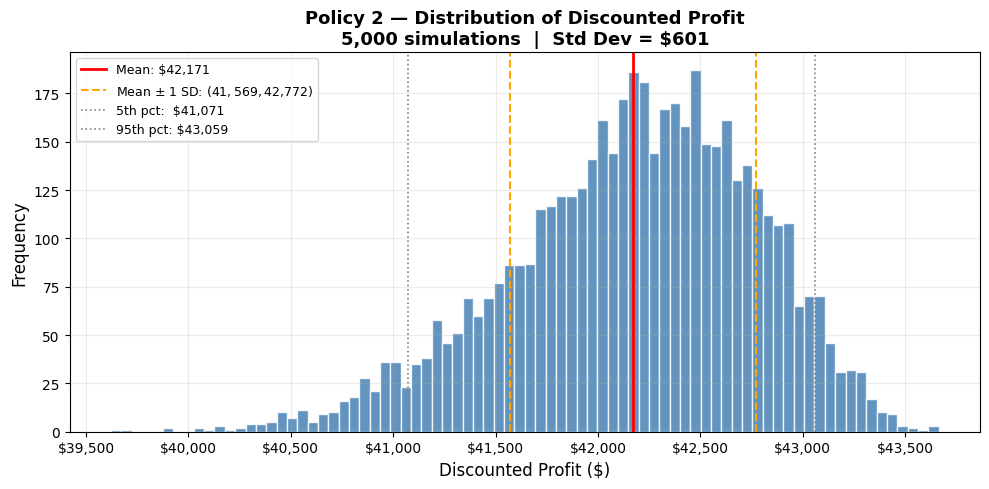

  Chart saved -> policy2_profit_distribution.png


In [29]:
# ── Histogram of Discounted Profits ──────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(all_profits, bins=80, color='steelblue', edgecolor='white', alpha=0.85)

ax.axvline(mean_profit,        color='red',    linewidth=2,   label=f'Mean: ${mean_profit:,.0f}')
ax.axvline(mean_profit - std_profit, color='orange', linewidth=1.5, linestyle='--',
           label=f'Mean ± 1 SD: (${mean_profit - std_profit:,.0f}, ${mean_profit + std_profit:,.0f})')
ax.axvline(mean_profit + std_profit, color='orange', linewidth=1.5, linestyle='--')
ax.axvline(p5,  color='grey', linewidth=1.2, linestyle=':',  label=f'5th pct:  ${p5:,.0f}')
ax.axvline(p95, color='grey', linewidth=1.2, linestyle=':',  label=f'95th pct: ${p95:,.0f}')

ax.set_xlabel('Discounted Profit ($)', fontsize=12)
ax.set_ylabel('Frequency',             fontsize=12)
ax.set_title(
    f'Policy 2 — Distribution of Discounted Profit\n'
    f'{N_SIM:,} simulations  |  Std Dev = ${std_profit:,.0f}',
    fontsize=13, fontweight='bold'
)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax.legend(fontsize=9)
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('policy2_profit_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('  Chart saved -> policy2_profit_distribution.png')